# USA Spending Awards EDA
Minimal review and cleanup of the raw awards parquet files before partitioning and publishing the curated dataset.

In [1]:
import os
import polars as pl
import polars.selectors as cs
from dotenv import load_dotenv
from huggingface_hub import HfApi, HfFileSystem
from tqdm import tqdm
from typing import IO, cast
import shutil
import re
import matplotlib.pyplot as plt

load_dotenv()

True

In [2]:
HF_TOKEN = os.getenv("HF_TOKEN")
HF_NAMESPACE = os.getenv("HF_NAMESPACE")
HF_BUCKET_NAME = os.getenv("HF_BUCKET_NAME")
OUTPUT_DATASET_REPO = os.getenv("OUTPUT_DATASET_REPO", "ggsmith/usa_spending_awards")

required_env = {
    "HF_TOKEN": HF_TOKEN,
    "HF_NAMESPACE": HF_NAMESPACE,
    "HF_BUCKET_NAME": HF_BUCKET_NAME,
}
missing_env = [name for name, value in required_env.items() if not value]
if missing_env:
    raise ValueError(f"Missing required environment variables: {', '.join(missing_env)}")


In [3]:
bucket_id = f"{HF_NAMESPACE}/{HF_BUCKET_NAME}"
parquet_path=f"hf://buckets/{bucket_id}/parquet/*.parquet"

fs = HfFileSystem()
# # Get all parquet files in the bucket folder
files = fs.glob(f"hf://buckets/{bucket_id}/parquet/*.parquet")
print("\n".join(f"- {f}" for f in files))

- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_1.parquet
- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_2.parquet
- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_3.parquet
- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_4.parquet
- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_5.parquet
- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_6.parquet
- buckets/ggsmith/usa-spending-raw/parquet/1f3130e95798_fy2022_All_Contracts_PrimeTransactions_2026-04-06_H00M16S20_7.parquet
- buckets/ggsmith/usa-spending-raw/parquet/494414914c50_fy2023_All_Contracts_PrimeTransactions_2026-04-05_H19M19S57_1.

In [4]:
dfs: list[pl.DataFrame] = []

for file in tqdm(files, desc="Loading files"):
    hash_match = re.search(r"([a-f0-9]{12})", file)
    year_match = re.search(r"fy(\d{4})", file)

    if hash_match is None or year_match is None:
        continue

    hash_var = hash_match.group(1)
    year_var = int(year_match.group(1))

    with fs.open(f"hf://{file}", "rb") as f:
        parquet_file = cast(IO[bytes], f)
        dfs.append(
            pl.read_parquet(parquet_file).with_columns(
                pl.lit(hash_var).alias("source_file_hash"),
                pl.lit(year_var).alias("fiscal_year"),
            )
        )
df = pl.concat(dfs, how="vertical_relaxed")

Loading files: 100%|██████████| 28/28 [00:35<00:00,  1.28s/it]


In [5]:
df.head()

award_id_piid,recipient_name,recipient_duns,period_of_performance_start_date,period_of_performance_current_end_date,transaction_description,current_total_value_of_award,awarding_agency_name,awarding_sub_agency_name,award_type,award_or_idv_flag,funding_agency_name,funding_sub_agency_name,naics_code,product_or_service_code,source_file_hash,fiscal_year
str,str,str,str,str,str,f64,str,str,str,str,str,str,i64,str,str,i32
"""W81XWH17P0109""","""OCULUS INC""",null,"""2017-03-21""","""2017-04-20""","""PENTACAM SCHEIMPLUG CAMERA""",62745.0,"""Department of Defense""","""Department of the Army""","""PURCHASE ORDER""","""AWARD""","""Department of Defense""","""Department of the Army""",339115,"""6540""","""1f3130e95798""",2022
"""W81XWH20C0147""","""CHEROKEE NATION OPERATIONAL SO…",null,"""2020-09-30""","""2023-09-30""","""PER SECTION 711 OF THE 2019 ND…",3.3946e6,"""Department of Defense""","""Department of the Army""","""DEFINITIVE CONTRACT""","""AWARD""","""Department of Defense""","""Defense Health Agency""",541513,"""D301""","""1f3130e95798""",2022
"""W81XWH22C0155""","""THE HENRY M. JACKSON FOUNDATIO…",null,"""2022-09-30""","""2023-09-29""","""PER THE 2017 711 NDAA, USAMRAA…",6.2860e6,"""Department of Defense""","""Department of the Army""","""DEFINITIVE CONTRACT""","""AWARD""","""Department of Defense""","""Uniformed Services University …",541715,"""AN11""","""1f3130e95798""",2022
"""05GA0A21F0054""","""AUGUST SCHELL ENTERPRISES, INC…",null,"""2021-09-30""","""2024-09-29""","""THE PURPOSE OF THIS MODIFICATI…",3.4192e6,"""Government Accountability Offi…","""GAO, Except Comptroller Genera…","""DELIVERY ORDER""","""AWARD""","""Government Accountability Offi…","""GAO, Except Comptroller Genera…",541519,"""DA01""","""1f3130e95798""",2022
"""1131PL23PSA41043""","""USI INSURANCE SERVICES LLC""",null,"""2023-01-25""","""2024-01-24""","""USI TRAVEL INSURANCE SERVICES …",11578.2,"""United States Trade and Develo…","""United States Trade and Develo…","""PURCHASE ORDER""","""AWARD""","""United States Trade and Develo…","""United States Trade and Develo…",561510,"""V302""","""1f3130e95798""",2022


In [6]:
raw_schema = df.collect_schema()
print(raw_schema)

Schema({'award_id_piid': String, 'recipient_name': String, 'recipient_duns': String, 'period_of_performance_start_date': String, 'period_of_performance_current_end_date': String, 'transaction_description': String, 'current_total_value_of_award': Float64, 'awarding_agency_name': String, 'awarding_sub_agency_name': String, 'award_type': String, 'award_or_idv_flag': String, 'funding_agency_name': String, 'funding_sub_agency_name': String, 'naics_code': Int64, 'product_or_service_code': String, 'source_file_hash': String, 'fiscal_year': Int32})


In [7]:
df.describe()

statistic,award_id_piid,recipient_name,recipient_duns,period_of_performance_start_date,period_of_performance_current_end_date,transaction_description,current_total_value_of_award,awarding_agency_name,awarding_sub_agency_name,award_type,award_or_idv_flag,funding_agency_name,funding_sub_agency_name,naics_code,product_or_service_code,source_file_hash,fiscal_year
str,str,str,str,str,str,str,f64,str,str,str,str,str,str,f64,str,str,f64
"""count""","""25617006""","""25616969""","""1147728""","""25616983""","""25617006""","""25617006""",2.5617006e7,"""25617006""","""25617006""","""25617006""","""25617006""","""25616994""","""25616994""",2.5615847e7,"""25616450""","""25617006""",2.5617006e7
"""null_count""","""0""","""37""","""24469278""","""23""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""12""","""12""",1159.0,"""556""","""0""",0.0
"""mean""",null,null,null,null,null,null,1.0217e7,null,null,null,null,null,null,386053.379835,null,null,2022.494242
"""std""",null,null,null,null,null,null,3.9824e8,null,null,null,null,null,null,90903.820112,null,null,1.115558
"""min""","""00001""","""""A-VET ROOFING & CONSTRUCTION,…","""100017073""","""1949-07-01""","""1995-12-31""","""!""",-1.2850e10,"""Administrative Conference of t…","""Administration for Children an…","""BPA CALL""","""AWARD""","""Access Board""","""Access Board""",111110.0,"""1005""","""1f3130e95798""",2021.0
"""25%""",null,null,null,null,null,null,155.7,null,null,null,null,null,null,324110.0,null,null,2021.0
"""50%""",null,null,null,null,null,null,645.06,null,null,null,null,null,null,336411.0,null,null,2022.0
"""75%""",null,null,null,null,null,null,8192.28,null,null,null,null,null,null,424210.0,null,null,2023.0
"""max""","""ZZ01""","""ÜBERSETZUNGSBÜRO AMIN GMBH""","""99990140""","""9019-07-29""","""8201-02-02""","""~15FT INFLATABLE BOAT. (1) DEL…",1.1117e11,"""United States Trade and Develo…","""Washington Headquarters Servic…","""PURCHASE ORDER""","""AWARD""","""United States Trade and Develo…","""Women's Bureau""",928120.0,"""Z300""","""9aba013a6da4""",2024.0


In [8]:
print(f"total record count: {df.height}")

null_counts = (
	df.null_count()
	.transpose(include_header=True, header_name="column", column_names=["null_count"])
	.sort("null_count", descending=True)
)
print(null_counts.filter(pl.col("null_count") > 0))

total record count: 25617006
shape: (7, 2)
┌─────────────────────────────────┬────────────┐
│ column                          ┆ null_count │
│ ---                             ┆ ---        │
│ str                             ┆ u32        │
╞═════════════════════════════════╪════════════╡
│ recipient_duns                  ┆ 24469278   │
│ naics_code                      ┆ 1159       │
│ product_or_service_code         ┆ 556        │
│ recipient_name                  ┆ 37         │
│ period_of_performance_start_da… ┆ 23         │
│ funding_agency_name             ┆ 12         │
│ funding_sub_agency_name         ┆ 12         │
└─────────────────────────────────┴────────────┘


- `duns_number` is the most frequently null field in the raw data.
- Other null-heavy columns appear limited relative to the full record count, with `naics_code` next.

In [9]:
# cardinality
cardinality_df = df.select(
    cs.by_dtype(pl.String, pl.Categorical ).n_unique()
)

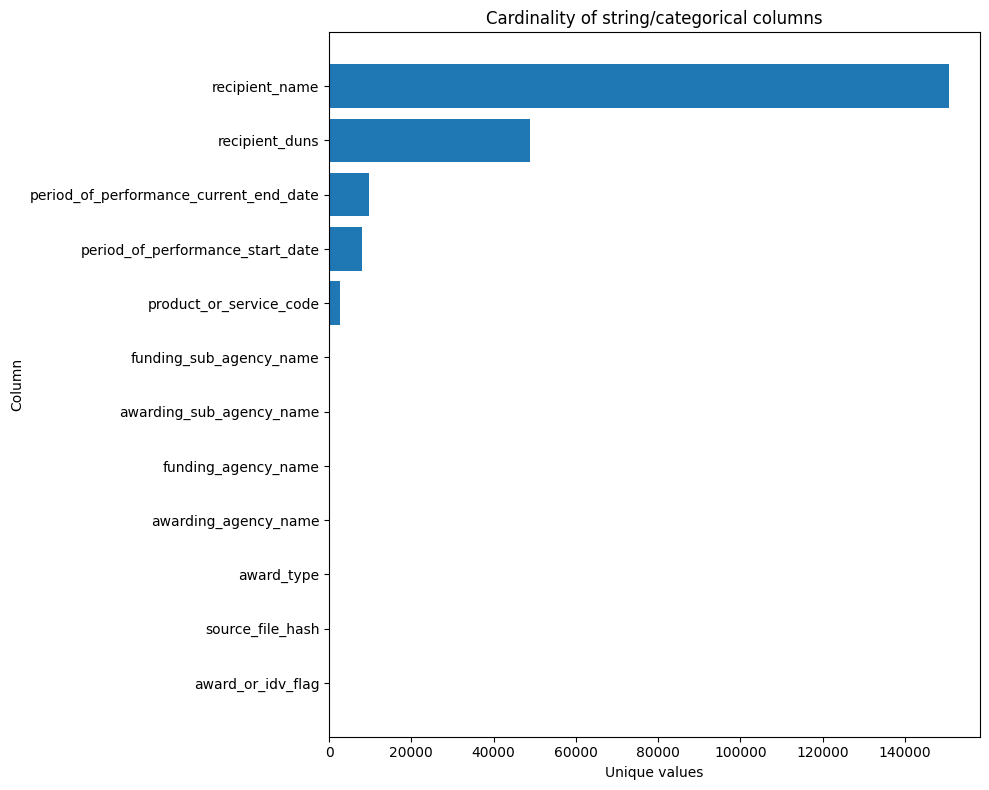

In [10]:
cardinality_long = (
    cardinality_df
    .transpose(include_header=True, header_name="column", column_names=["count"])
    .with_columns(pl.col("count").cast(pl.Int64))
    .sort("count", descending=True)
    .filter((pl.col("column") != "award_id_piid") & (pl.col("column") != "transaction_description"))
)


plt.figure(figsize=(10, 8))
plt.barh(
    cardinality_long["column"].to_list()[::-1],
    cardinality_long["count"].to_list()[::-1],
)
plt.xlabel("Unique values")
plt.ylabel("Column")
plt.title("Cardinality of string/categorical columns")
plt.tight_layout()
plt.show()


In [11]:
cardinality_long.sort("count", descending=False).filter(pl.col("count")< 100)

column,count
str,i64
"""award_or_idv_flag""",1
"""source_file_hash""",4
"""award_type""",4
"""awarding_agency_name""",70
"""funding_agency_name""",97


# Data Type Conversion


In [12]:
# raw data
df.head(3)

award_id_piid,recipient_name,recipient_duns,period_of_performance_start_date,period_of_performance_current_end_date,transaction_description,current_total_value_of_award,awarding_agency_name,awarding_sub_agency_name,award_type,award_or_idv_flag,funding_agency_name,funding_sub_agency_name,naics_code,product_or_service_code,source_file_hash,fiscal_year
str,str,str,str,str,str,f64,str,str,str,str,str,str,i64,str,str,i32
"""W81XWH17P0109""","""OCULUS INC""",null,"""2017-03-21""","""2017-04-20""","""PENTACAM SCHEIMPLUG CAMERA""",62745.0,"""Department of Defense""","""Department of the Army""","""PURCHASE ORDER""","""AWARD""","""Department of Defense""","""Department of the Army""",339115,"""6540""","""1f3130e95798""",2022
"""W81XWH20C0147""","""CHEROKEE NATION OPERATIONAL SO…",null,"""2020-09-30""","""2023-09-30""","""PER SECTION 711 OF THE 2019 ND…",3.3946e6,"""Department of Defense""","""Department of the Army""","""DEFINITIVE CONTRACT""","""AWARD""","""Department of Defense""","""Defense Health Agency""",541513,"""D301""","""1f3130e95798""",2022
"""W81XWH22C0155""","""THE HENRY M. JACKSON FOUNDATIO…",null,"""2022-09-30""","""2023-09-29""","""PER THE 2017 711 NDAA, USAMRAA…",6.2860e6,"""Department of Defense""","""Department of the Army""","""DEFINITIVE CONTRACT""","""AWARD""","""Department of Defense""","""Uniformed Services University …",541715,"""AN11""","""1f3130e95798""",2022


In [13]:
df_clean = df.with_columns(
    # cast date strings to date type
    pl.col("period_of_performance_start_date").str.to_date(),
    pl.col("period_of_performance_current_end_date").str.to_date(),

    # cast float to string
    pl.col("naics_code").cast(pl.String()),
    pl.col("fiscal_year").cast(pl.String()),
    
    # normalize transaction description 
    pl.col("transaction_description")
    .str.to_uppercase()  
    .str.replace_all(r"[^A-Z0-9]+", "")
    .alias("transaction_description_norm")
)

In [14]:
df_clean.head()

award_id_piid,recipient_name,recipient_duns,period_of_performance_start_date,period_of_performance_current_end_date,transaction_description,current_total_value_of_award,awarding_agency_name,awarding_sub_agency_name,award_type,award_or_idv_flag,funding_agency_name,funding_sub_agency_name,naics_code,product_or_service_code,source_file_hash,fiscal_year,transaction_description_norm
str,str,str,date,date,str,f64,str,str,str,str,str,str,str,str,str,str,str
"""W81XWH17P0109""","""OCULUS INC""",null,2017-03-21,2017-04-20,"""PENTACAM SCHEIMPLUG CAMERA""",62745.0,"""Department of Defense""","""Department of the Army""","""PURCHASE ORDER""","""AWARD""","""Department of Defense""","""Department of the Army""","""339115""","""6540""","""1f3130e95798""","""2022""","""PENTACAMSCHEIMPLUGCAMERA"""
"""W81XWH20C0147""","""CHEROKEE NATION OPERATIONAL SO…",null,2020-09-30,2023-09-30,"""PER SECTION 711 OF THE 2019 ND…",3.3946e6,"""Department of Defense""","""Department of the Army""","""DEFINITIVE CONTRACT""","""AWARD""","""Department of Defense""","""Defense Health Agency""","""541513""","""D301""","""1f3130e95798""","""2022""","""PERSECTION711OFTHE2019NDAAUSAM…"
"""W81XWH22C0155""","""THE HENRY M. JACKSON FOUNDATIO…",null,2022-09-30,2023-09-29,"""PER THE 2017 711 NDAA, USAMRAA…",6.2860e6,"""Department of Defense""","""Department of the Army""","""DEFINITIVE CONTRACT""","""AWARD""","""Department of Defense""","""Uniformed Services University …","""541715""","""AN11""","""1f3130e95798""","""2022""","""PERTHE2017711NDAAUSAMRAAAHASTR…"
"""05GA0A21F0054""","""AUGUST SCHELL ENTERPRISES, INC…",null,2021-09-30,2024-09-29,"""THE PURPOSE OF THIS MODIFICATI…",3.4192e6,"""Government Accountability Offi…","""GAO, Except Comptroller Genera…","""DELIVERY ORDER""","""AWARD""","""Government Accountability Offi…","""GAO, Except Comptroller Genera…","""541519""","""DA01""","""1f3130e95798""","""2022""","""THEPURPOSEOFTHISMODIFICATIONIS…"
"""1131PL23PSA41043""","""USI INSURANCE SERVICES LLC""",null,2023-01-25,2024-01-24,"""USI TRAVEL INSURANCE SERVICES …",11578.2,"""United States Trade and Develo…","""United States Trade and Develo…","""PURCHASE ORDER""","""AWARD""","""United States Trade and Develo…","""United States Trade and Develo…","""561510""","""V302""","""1f3130e95798""","""2022""","""USITRAVELINSURANCESERVICESOBLI…"


# Award ID / PIID Duplicate Review

In [15]:
award_id_by_count = (
    df_clean.group_by(pl.col("award_id_piid")).len().sort(by=pl.col("len"), descending=True)

)

In [16]:
duplicate_award_ids = award_id_by_count.filter(pl.col("len") > 1)
duplicate_award_ids

award_id_piid,len
str,u32
"""0001""",4573
"""0002""",3908
"""0003""",2470
"""0005""",1883
"""0004""",1723
…,…
"""W912HP24F6028""",2
"""FA480024C0010""",2
"""HC108425FA385""",2


In [17]:
df_clean.filter(pl.col("award_id_piid") == "0001")

award_id_piid,recipient_name,recipient_duns,period_of_performance_start_date,period_of_performance_current_end_date,transaction_description,current_total_value_of_award,awarding_agency_name,awarding_sub_agency_name,award_type,award_or_idv_flag,funding_agency_name,funding_sub_agency_name,naics_code,product_or_service_code,source_file_hash,fiscal_year,transaction_description_norm
str,str,str,date,date,str,f64,str,str,str,str,str,str,str,str,str,str,str
"""0001""","""LYNKER CORPORATION""",null,2017-09-30,2020-09-29,"""DE-OBLIGATION""",1.2456e6,"""Department of Education""","""Department of Education""","""BPA CALL""","""AWARD""","""Department of Education""","""Department of Education""","""541513""","""R410""","""1f3130e95798""","""2022""","""DEOBLIGATION"""
"""0001""","""BASTION TECHNOLOGIES, INC.""",null,2014-09-30,2020-09-29,"""AMCOM SAFETY OFFICE""",1.4351e7,"""Department of Defense""","""Department of the Army""","""BPA CALL""","""AWARD""","""Department of Defense""","""Department of the Army""","""541330""","""R425""","""1f3130e95798""","""2022""","""AMCOMSAFETYOFFICE"""
"""0001""","""LUNARLINE, INC.""",null,2015-09-30,2020-09-29,"""SOFITS ISS TASK ORDER 1 - TRAN…",6985837.4,"""Department of Transportation""","""Immediate Office of the Secret…","""DELIVERY ORDER""","""AWARD""","""Department of Transportation""","""Immediate Office of the Secret…","""541519""","""D306""","""1f3130e95798""","""2022""","""SOFITSISSTASKORDER1TRANSITIONM…"
"""0001""","""DOYON MANAGEMENT SERVICES, LLC""",null,2017-06-01,2023-01-31,"""CHEMISTRY LABORATORY RENOVATIO…",1.2434e7,"""Environmental Protection Agenc…","""Environmental Protection Agenc…","""DELIVERY ORDER""","""AWARD""","""Environmental Protection Agenc…","""Environmental Protection Agenc…","""236220""","""Y1DB""","""1f3130e95798""","""2022""","""CHEMISTRYLABORATORYRENOVATIONP…"
"""0001""","""ARCTOS TECHNOLOGY SOLUTIONS, L…",null,2015-09-29,2024-09-29,"""RESEARCH INITIATIVES IN MATERI…",845126.0,"""Department of Defense""","""Department of the Air Force""","""DELIVERY ORDER""","""AWARD""","""Department of Defense""","""Department of the Air Force""","""541712""","""AC12""","""1f3130e95798""","""2022""","""RESEARCHINITIATIVESINMATERIALS…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""0001""","""BURLESON CONSULTING, INC.""",null,2017-07-01,2020-03-20,"""TASK 1.1.1 -- PROJECT STATUS U…",373216.39,"""Department of Defense""","""Department of the Army""","""DELIVERY ORDER""","""AWARD""","""Department of Defense""","""Department of the Army""","""541620""","""F999""","""9aba013a6da4""","""2024""","""TASK111PROJECTSTATUSUPDATEREPO"""
"""0001""","""AMENTUM SERVICES, INC.""",null,2015-04-21,2024-09-30,"""DEOBLIGATE FY20 EXCESS FUNDS""",3.7882e8,"""Department of Defense""","""Department of the Army""","""DELIVERY ORDER""","""AWARD""","""Department of Defense""","""Department of the Army""","""561210""","""R706""","""9aba013a6da4""","""2024""","""DEOBLIGATEFY20EXCESSFUNDS"""
"""0001""","""ALIGN PRECISION - CEDAR CITY, …",null,2015-09-29,2026-12-31,"""A-10 NACELLE""",2.1650e7,"""Department of Defense""","""Defense Logistics Agency""","""DELIVERY ORDER""","""AWARD""","""Department of Defense""","""Department of the Air Force""","""336413""","""1560""","""9aba013a6da4""","""2024""","""A10NACELLE"""


In [18]:
award_id_by_count_fy = (
    df_clean.group_by([pl.col("award_id_piid"), pl.col("fiscal_year")]).len().sort(by=pl.col("len"), descending=True)
)

In [19]:
award_id_by_count_fy.filter(pl.col("len") > 1).sort(by=pl.col("fiscal_year"))

award_id_piid,fiscal_year,len
str,str,u32
"""0001""","""2021""",1878
"""0002""","""2021""",1648
"""0003""","""2021""",947
"""0005""","""2021""",730
"""0004""","""2021""",669
…,…,…
"""SPE4A725F7369""","""2024""",2
"""36C24524C0065""","""2024""",2
"""15B20825F00000040""","""2024""",2


In [20]:
# drop duplicate rows
df_deduplicated = df_clean.unique()

In [21]:
print(f"source rows: {df_clean.height} | deduped rows: {df_deduplicated.height}| diff {df_clean.height-df_deduplicated.height}") 

source rows: 25617006 | deduped rows: 24893673| diff 723333


In [22]:
deduped_award_id_by_count_fy = (
    df_deduplicated.group_by([pl.col("award_id_piid"), pl.col("fiscal_year")]).len().sort(by=pl.col("len"), descending=True)
).filter(pl.col("len") > 1)

In [23]:
deduped_award_id_by_count_fy

award_id_piid,fiscal_year,len
str,str,u32
"""0001""","""2021""",1662
"""0002""","""2021""",1416
"""0001""","""2022""",1075
"""0002""","""2022""",923
"""0003""","""2021""",843
…,…,…
"""SPE4A624V1798""","""2023""",2
"""88310325F00001""","""2024""",2
"""12444122F0102""","""2022""",2


In [24]:
year_dup_summary = (
    award_id_by_count_fy
    .filter(pl.col("len") > 1)
    .group_by("fiscal_year")
    .agg([
        pl.len().alias("duplicated_award_ids"),
        (pl.col("len") - 1).sum().alias("excess_duplicate_rows"),
    ])
    .sort("fiscal_year")
)

year_dup_summary

fiscal_year,duplicated_award_ids,excess_duplicate_rows
str,u32,u32
"""2021""",388195,686711
"""2022""",381211,653249
"""2023""",357411,644779
"""2024""",339007,618601


In [25]:
year_dup_summary.select(pl.col("excess_duplicate_rows")).sum()

excess_duplicate_rows
u32
2603340


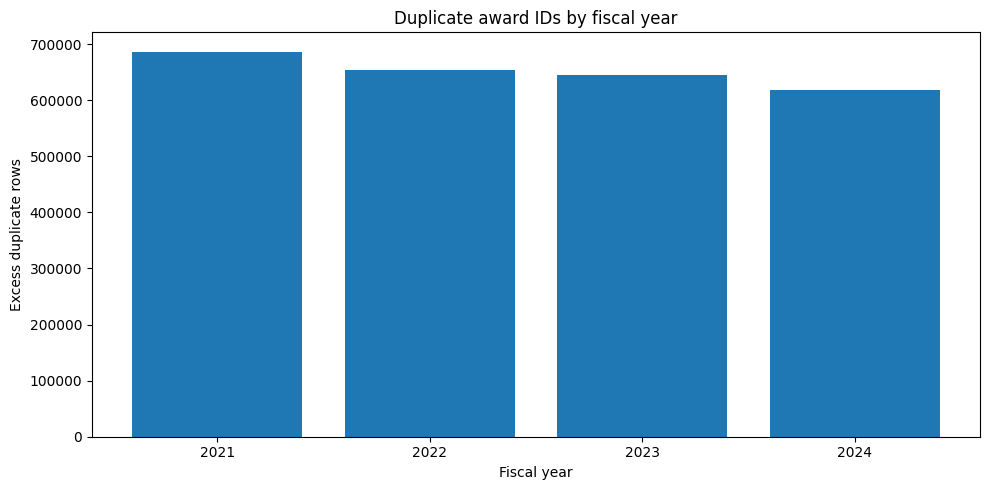

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(
    year_dup_summary["fiscal_year"].to_list(),
    year_dup_summary["excess_duplicate_rows"].to_list(),
)
plt.xlabel("Fiscal year")
plt.ylabel("Excess duplicate rows")
plt.title("Duplicate award IDs by fiscal year")
plt.xticks(year_dup_summary["fiscal_year"].to_list())
plt.tight_layout()
plt.show()


In [28]:
deduped_award_id_by_count_fy.filter(pl.col("fiscal_year") == '2023')

award_id_piid,fiscal_year,len
str,str,u32
"""0001""","""2023""",776
"""0002""","""2023""",636
"""0003""","""2023""",471
"""0005""","""2023""",345
"""0004""","""2023""",324
…,…,…
"""70Z03424PHONO0013""","""2023""",2
"""47QSHA24F04CU""","""2023""",2
"""15B31324P00000025""","""2023""",2


Most duplicate rows remain when `source_file_hash` and `fiscal_year` are included, which suggests some awards carry across fiscal years.

In [29]:
# deduplicate dataframe ignoring file hash and fiscal year
df_exact_deduped = df_deduplicated.unique(
    subset=[
        c for c in df.columns 
        if c not in ["source_file_hash", "fiscal_year"]
    ],
    maintain_order=True,
    keep="first"
)

In [30]:
business_key = [
    "recipient_name",
    "transaction_description_norm",
    "current_total_value_of_award",
    "awarding_agency_name",
    "award_type",
    "period_of_performance_start_date",
]

df_curated = df_exact_deduped.unique(
    subset=business_key,
    maintain_order=True,
    keep="last",
).drop("transaction_description_norm")


In [31]:
df_curated.shape


(23431133, 17)

In [32]:
df_curated.head(3)

award_id_piid,recipient_name,recipient_duns,period_of_performance_start_date,period_of_performance_current_end_date,transaction_description,current_total_value_of_award,awarding_agency_name,awarding_sub_agency_name,award_type,award_or_idv_flag,funding_agency_name,funding_sub_agency_name,naics_code,product_or_service_code,source_file_hash,fiscal_year
str,str,str,date,date,str,f64,str,str,str,str,str,str,str,str,str,str
"""SPE3SU25F49EC""","""LOFFREDO GARDENS, INC""",null,2024-12-02,2024-12-02,"""4566578777!LETTUCE, CHL,""",639.65,"""Department of Defense""","""Defense Logistics Agency""","""DELIVERY ORDER""","""AWARD""","""Department of Defense""","""Defense Logistics Agency""","""311991""","""8915""","""9aba013a6da4""","""2024"""
"""SPE2DM25F4Z43""","""OWENS & MINOR DISTRIBUTION INC""",null,2025-06-02,2025-06-24,"""4568431453!CEFTRIAXONE 1 GM-D5…",501.6,"""Department of Defense""","""Defense Logistics Agency""","""DELIVERY ORDER""","""AWARD""","""Department of Defense""","""Defense Logistics Agency""","""423450""","""6515""","""9aba013a6da4""","""2024"""
"""47QSCC22F1GPE""","""MSC INDUSTRIAL DIRECT CO., INC…","""932619265""",2022-01-25,2022-02-01,"""8200 N95 20/BOX 3M PARTICULATE…",315.5,"""General Services Administratio…","""Federal Acquisition Service""","""BPA CALL""","""AWARD""","""General Services Administratio…","""Federal Acquisition Service""","""444130""","""5120""","""864e6c55f94b""","""2021"""


# Partition and Publish
Write curated parquet files partitioned by fiscal year and award type, then upload them to the dataset repo.

In [33]:
# reset the local export directory before writing partitioned parquet files
folder_path = "data/processed"

if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

os.makedirs(folder_path, exist_ok=True)

df_curated.write_parquet(
    file=folder_path,
    compression="zstd",
    partition_by=["fiscal_year", "award_type"],
)

In [34]:
# push curated parquet files to the Hub dataset repo
hf = HfApi(token=HF_TOKEN)
hf.upload_folder(
    folder_path=folder_path,
    repo_id=OUTPUT_DATASET_REPO,
    repo_type="dataset",
    path_in_repo="data/awards/",
    commit_message="upload fixed dtypes"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/ggsmith/usa_spending_awards/commit/1395dd447b4f2283ba985a1214a2e8349e4a5012', commit_message='upload fixed dtypes', commit_description='', oid='1395dd447b4f2283ba985a1214a2e8349e4a5012', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/ggsmith/usa_spending_awards', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ggsmith/usa_spending_awards'), pr_revision=None, pr_num=None)

In [35]:
# optional local cleanup after upload

if os.path.exists(folder_path):
    shutil.rmtree(folder_path)
    print(f"Successfully deleted {folder_path}")


Successfully deleted data/processed
